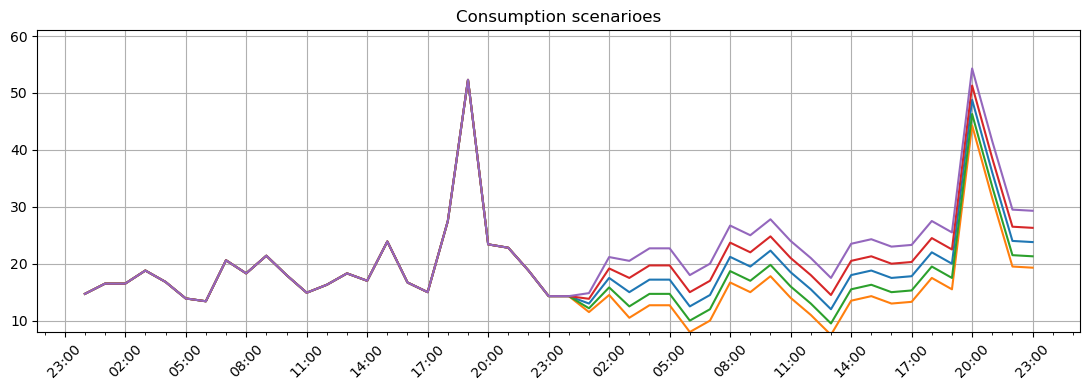

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ------------------------------------------------------------------
# 1. Historical consumption (shared by all scenarios), hourly
#    from 01-06 00:00 to 01-06 23:00 (approximate values read off the plot)
# ------------------------------------------------------------------
hist_values = [
    14.7, 16.5, 16.5, 18.8, 16.8, 13.9, 13.4, 20.6,   # 00-07
    18.3, 21.4, 18.0, 14.9, 16.3, 18.3, 17.0, 23.9,   # 08-15
    16.7, 15.0, 27.5, 52.3, 23.4, 22.8, 18.8, 14.3,   # 16-23
]
hist_idx = pd.date_range("2024-01-06 00:00", periods=len(hist_values), freq="h")
hist = pd.Series(hist_values, index=hist_idx)

# ------------------------------------------------------------------
# 2. Base forecast for 01-07 (approximate), hourly 00:00 -> 23:00
# ------------------------------------------------------------------
base_forecast = [
    14.3, 13.0, 17.5, 15.0, 17.2, 17.2, 12.5, 14.5,   # 00-07
    21.2, 19.5, 22.3, 18.5, 15.5, 12.0, 18.0, 18.8,   # 08-15
    17.5, 17.8, 22.0, 20.0, 48.8, 36.0, 24.0, 23.8,   # 16-23
]
fc_idx = pd.date_range("2024-01-07 00:00", periods=len(base_forecast), freq="h")
base = pd.Series(base_forecast, index=fc_idx)

# Scenario offsets (relative to the base/blue line)
offsets = {
    "scenario_1": 0.0,    # blue
    "scenario_2": -4.5,   # orange
    "scenario_3": -2.5,   # green
    "scenario_4": +2.5,   # red
    "scenario_5": +5.5,   # purple
}

# Forecast starts at the last historical point so lines connect smoothly
connect_point = hist.iloc[[-1]]

# ------------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------------


def plot_consumption_scenarios(hist, base, offsets, figtitle, show_grid=True, despine=False, new_x=False,plottype='line'):
    fig, ax = plt.subplots(figsize=(11, 4))

    # Matplotlib default color cycle: blue, orange, green, red, purple
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

    for (name, off), color in zip(offsets.items(), colors):
        scenario = base + off
        # Taper the offset in over the first few hours so scenarios fan out
        ramp = np.clip(np.arange(len(scenario)) / 3.0, 0, 1)
        scenario = base + off * ramp
        full = pd.concat([hist, scenario])
        # Plot history + scenario as one line per scenario
        if plottype == 'step':
            ax.step(full.index, full.values, color=color, label=name, where='post')
        else:
            ax.plot(full.index, full.values, color=color, label=name)

        if new_x:
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
            ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            plt.xticks(rotation=45)

    ax.set_title(figtitle)
    ax.set_ylim(8, 61)
    ax.grid(show_grid)

   

    if despine:
        sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

plot_consumption_scenarios(hist, base, offsets, figtitle="Consumption scenarioes", new_x=True, plottype='line')

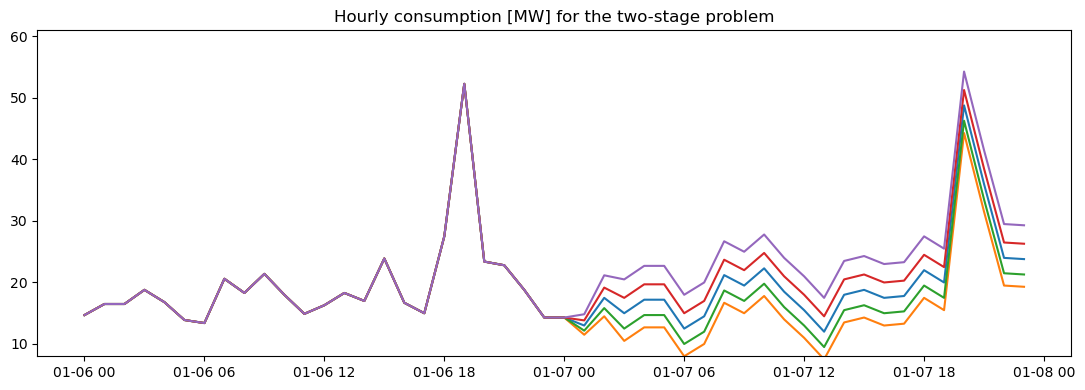

In [38]:
#Removing the grid and fixing the title (acting as caption)
newtitle = "Hourly consumption [MW] for the two-stage problem"

plot_consumption_scenarios(hist, base, offsets, figtitle=newtitle, show_grid=False)

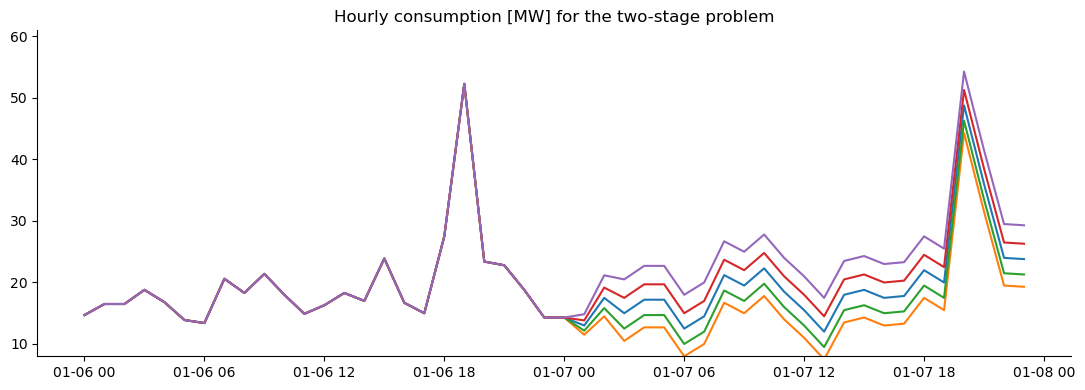

In [39]:
#despining
plot_consumption_scenarios(hist, base, offsets, figtitle=newtitle, show_grid=False, despine=True)

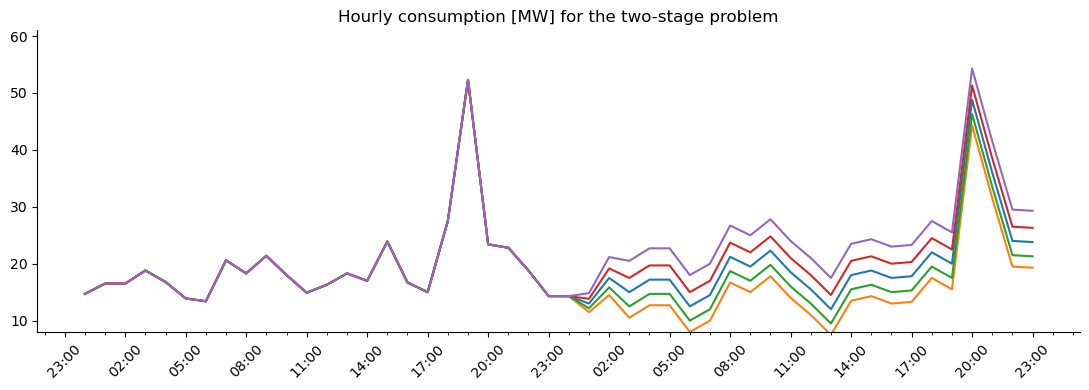

In [40]:
#cleaning up x-axis 
plot_consumption_scenarios(hist, base, offsets, figtitle=newtitle, show_grid=False, despine=True, new_x=True)

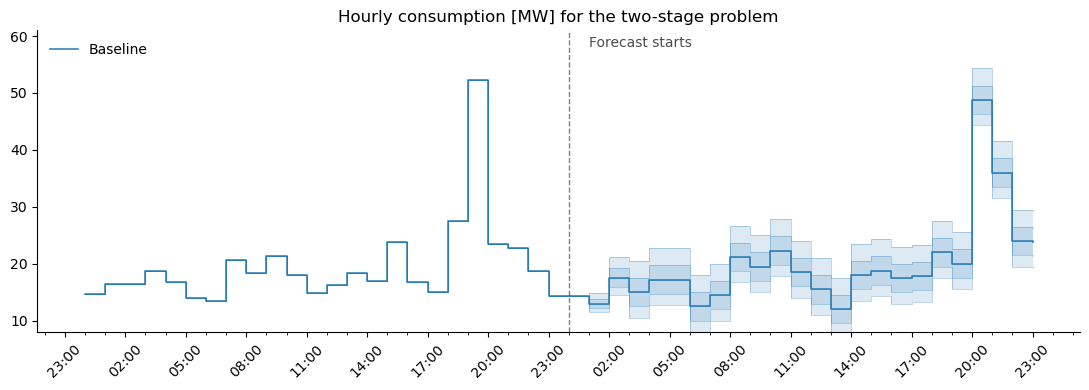

In [49]:
#Yet an even better option 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


def plot_consumption_bands(hist, base, offsets, figtitle, show_grid=False,
                           despine=True, new_x=True, plottype="line",
                           band_alpha=0.15, base_color="tab:blue"):
    """
    Baseline + scenario bands.

    - Baseline: history + `base` forecast, thin line with slightly higher alpha.
    - Bands: nested light shading between scenarios, sorted by offset
      (outermost = min/max scenario, inner = next pair, ...).
    - Scenario edges: very thin, faint lines so each level is still readable.
    """
    fig, ax = plt.subplots(figsize=(11, 4))
    draw = ax.step if plottype == "step" else ax.plot
    kw = {"where": "post"} if plottype == "step" else {}

    # Build the scenario paths, with the same ramp as before so they fan out
    # smoothly from the end of the history
    ramp = np.clip(np.arange(len(base)) / 3.0, 0, 1)
    scen = pd.DataFrame({n: base + o * ramp for n, o in offsets.items()})
    scen = scen[sorted(scen.columns, key=lambda n: offsets[n])]  # low -> high

    # Baseline path = history + base forecast; scenarios share the history
    base_full = pd.concat([hist, base])

    def with_hist(s):
        return pd.concat([hist, s])

    # ---- Nested bands: pair lowest with highest, 2nd lowest with 2nd highest..
    paths = [with_hist(scen[c]) for c in scen.columns]
    n = len(paths)
    n_bands = n // 2
    for i in range(n_bands):
        lo, hi = paths[i], paths[n - 1 - i]
        ax.fill_between(lo.index, lo.values, hi.values, color=base_color,
                        alpha=band_alpha, linewidth=0,
                        step="post" if plottype == "step" else None)

    # If odd number of scenarios, the middle one sits inside the bands as a
    # faint line; we also draw all scenario edges very lightly
    for p in paths:
        draw(p.index, p.values, color=base_color, lw=0.6, alpha=0.35, **kw)

    # ---- Baseline: not bold, just slightly higher alpha
    draw(base_full.index, base_full.values, color=base_color, lw=1.2,
         alpha=0.9, label="Baseline", **kw)

    # ---- Cosmetics (same options as the original helper)
    if new_x:
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
        ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        plt.xticks(rotation=45)

    #add a vline with dashed line at the end of the history to indicate the start of the forecast
    ax.axvline(x=hist.index[-1]+ pd.Timedelta(hours=1), color='black', linestyle='--', linewidth=1, alpha=0.5)
    #add text to the right of the vline to indicate the start of the forecast
    ax.text(hist.index[-1] + pd.Timedelta(hours=2), 60, "Forecast starts", rotation=0, verticalalignment='top', fontsize=10, alpha=0.7)
    ax.set_title(figtitle)
    ax.set_ylim(8, 61)
    ax.grid(show_grid)
    ax.legend(loc="upper left", frameon=False)
    if despine:
        sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


# Usage (hist, base, offsets as defined earlier in the notebook)
plot_consumption_bands(
    hist, base, offsets,
    figtitle="Hourly consumption [MW] for the two-stage problem", plottype="step"
)



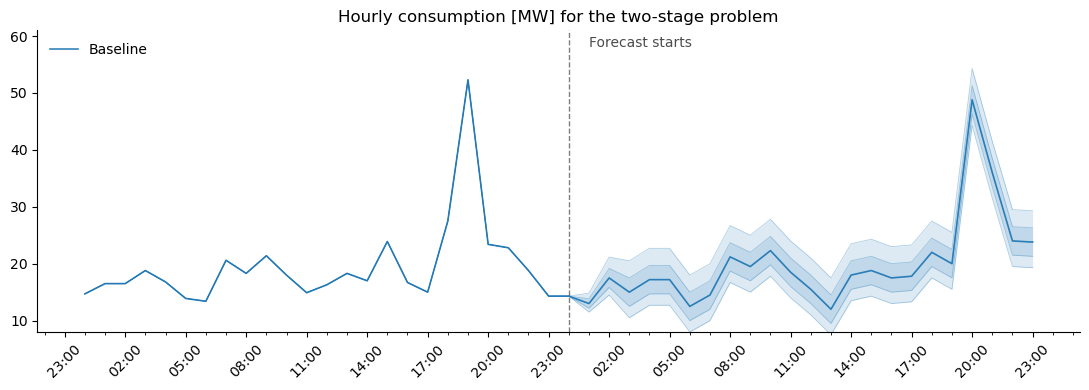

In [ ]:
plot_consumption_bands(
    hist, base, offsets,
    figtitle="Hourly consumption [MW] for the two-stage problem", plottype="line"
)
#export pdf
plot.savefig("consumption_bands.pdf", bbox_inches="tight")